APPLYING SIM TO HARDWARE
HARDWARE CHECK:

In [1]:
import time
import numpy as np

from hardware_ops import HardwareOps
import Simulation as S
import alignment_ops as A

In [79]:
import importlib
importlib.reload(S)
importlib.reload(A)

<module 'alignment_ops' from 'c:\\Users\\alber\\Desktop\\Sim Fol\\alignment_ops.py'>

In [2]:
# Initialize hardware
H = HardwareOps("hardware_config.json")

In [3]:
def read_qc():
    vals = np.array(H.quads.get_xy_position(), dtype=float)
    print(f"QC: x1={vals[0]:+.4f}, y1={vals[1]:+.4f}, x2={vals[2]:+.4f}, y2={vals[3]:+.4f}")
    return vals

def qc_y(vals):
    return np.array([vals[1], vals[3]], dtype=float)

def check_qc_safe(vals, limit=3.5):
    y = qc_y(vals)
    if np.max(np.abs(y)) > limit:
        raise RuntimeError(f"QC y too close to edge: {y}, limit={limit}")
    return True

def read_qc_repeated(n=5, delay=0.3, limit=3.5):
    vals = []
    for _ in range(n):
        v = read_qc()
        check_qc_safe(v, limit=limit)
        vals.append(v)
        time.sleep(delay)
    vals = np.array(vals)
    mean = vals.mean(axis=0)
    std = vals.std(axis=0)
    print("mean:", mean)
    print("std: ", std)
    return mean, std, vals

In [4]:
read_qc()

QC: x1=+0.4800, y1=-0.2259, x2=+0.1133, y2=-0.4723


array([ 0.4799638 , -0.22586532,  0.11334036, -0.47225149])

In [5]:
def test_linear_stage_mm(serial, delta=0.05):
    p0 = H.stages.get_position(serial)
    print("before:", p0)

    H.stages.move_relative(serial, delta)
    time.sleep(1.0)
    p1 = H.stages.get_position(serial)
    print("after +:", p1, "delta:", p1 - p0)

    H.stages.move_relative(serial, -delta)
    time.sleep(1.0)
    p2 = H.stages.get_position(serial)
    print("after back:", p2, "residual:", p2 - p0)

    return p0, p1, p2

In [6]:
test_linear_stage_mm("27266901", delta=0.5)

before: 0.0
Moving KDC101 stage 27266901 to 0.5 mm
Move complete for 27266901
after +: 0.5 delta: 0.5
Moving KDC101 stage 27266901 to 0.0 mm
Move complete for 27266901
after back: 0.0 residual: 0.0


(0.0, 0.5, 0.0)

In [7]:
def rotation_direction_test(label="M1.dangle", test_steps=5, settle=0.8, qc_limit=3.5):
    mapping = A.DEFAULT_ACTUATOR_MAP[label]
    controller = mapping["controller"]
    actuator = mapping["actuator"]
    direction = int(np.sign(mapping.get("direction", 1)) or 1)

    print(f"Testing {label}: controller={controller}, actuator={actuator}, test_steps={test_steps}")

    print("\nBefore:")
    before, before_std, _ = read_qc_repeated(n=3, delay=0.3, limit=qc_limit)

    cmd_steps = direction * int(test_steps)
    print(f"\nMoving + test: {cmd_steps} substeps")
    H.rotation_stages.move_relative_steps(controller, actuator, cmd_steps)
    time.sleep(settle)

    print("\nAfter + move:")
    after_plus, plus_std, _ = read_qc_repeated(n=3, delay=0.3, limit=qc_limit)

    print(f"\nMoving back: {-cmd_steps} substeps")
    H.rotation_stages.move_relative_steps(controller, actuator, -cmd_steps)
    time.sleep(settle)

    print("\nAfter back:")
    after_back, back_std, _ = read_qc_repeated(n=3, delay=0.3, limit=qc_limit)

    dy_plus = qc_y(after_plus) - qc_y(before)
    dy_back_residual = qc_y(after_back) - qc_y(before)

    print("\nSummary")
    print("dy after + move:", dy_plus)
    print("residual after back:", dy_back_residual)

    return {
        "label": label,
        "controller": controller,
        "actuator": actuator,
        "test_steps": int(test_steps),
        "before": before,
        "after_plus": after_plus,
        "after_back": after_back,
        "dy_plus": dy_plus,
        "dy_back_residual": dy_back_residual,
        "before_std": before_std,
        "plus_std": plus_std,
        "back_std": back_std,
    }

In [8]:
test_M1 = rotation_direction_test("M1.dangle", test_steps=5)

Testing M1.dangle: controller=newport, actuator=1, test_steps=5

Before:
QC: x1=+0.4642, y1=-0.2785, x2=+0.0998, y2=-0.5416
QC: x1=+0.4626, y1=-0.2775, x2=+0.0995, y2=-0.5403
QC: x1=+0.4659, y1=-0.2795, x2=+0.1002, y2=-0.5344
mean: [ 0.46423197 -0.27853918  0.09983577 -0.53878461]
std:  [0.0013684  0.00082104 0.00027706 0.00313842]

Moving + test: 5 substeps

After + move:
QC: x1=+1.6254, y1=-0.2803, x2=+1.9867, y2=-0.5542
QC: x1=+1.6210, y1=-0.2795, x2=+1.9951, y2=-0.5566
QC: x1=+1.6210, y1=-0.3128, x2=+1.9906, y2=-0.5591
mean: [ 1.62243007 -0.29089065  1.99081211 -0.55661537]
std:  [0.00209043 0.0155062  0.00344294 0.00199699]

Moving back: -5 substeps

After back:
QC: x1=+0.9669, y1=-0.2795, x2=+0.8550, y2=-0.5476
QC: x1=+0.9599, y1=-0.2775, x2=+0.8540, y2=-0.5502
QC: x1=+0.9669, y1=-0.2795, x2=+0.8540, y2=-0.5565
mean: [ 0.96456493 -0.27887558  0.85431536 -0.55143881]
std:  [0.00327909 0.00094805 0.00049273 0.00374663]

Summary
dy after + move: [-0.01235147 -0.01783075]
residual af

In [15]:
test_M2 = rotation_direction_test("M2.dangle", test_steps=5)

Testing M2.dangle: controller=newport, actuator=3, test_steps=5

Before:
QC: x1=+0.7603, y1=+0.6261, x2=+0.8275, y2=+0.6696
QC: x1=+0.7603, y1=+0.6261, x2=+0.8220, y2=+0.6690
QC: x1=+0.7603, y1=+0.6261, x2=+0.8227, y2=+0.6734
mean: [0.76028454 0.62611668 0.82404461 0.67069907]
std:  [0.         0.         0.00245923 0.00195267]

Moving + test: 5 substeps

After + move:
QC: x1=-1.0524, y1=+0.6139, x2=-1.4432, y2=+0.6437
QC: x1=-1.0776, y1=+0.6139, x2=-1.4679, y2=+0.6414
QC: x1=-1.0333, y1=+0.6156, x2=-1.4439, y2=+0.6365
mean: [-1.0544177   0.61444735 -1.45163221  0.64053953]
std:  [0.01812836 0.0008106  0.01147173 0.0030147 ]

Moving back: -5 substeps

After back:
QC: x1=+0.4696, y1=+0.6594, x2=+0.4581, y2=+0.6755
QC: x1=+0.4696, y1=+0.6594, x2=+0.4628, y2=+0.6833
QC: x1=+0.4906, y1=+0.6576, x2=+0.4700, y2=+0.6916
mean: [0.47657542 0.65881727 0.46364748 0.68348617]
std:  [0.0098824  0.00088314 0.00489655 0.00660021]

Summary
dy after + move: [-0.01166933 -0.03015954]
residual after back

In [9]:
test_M4 = rotation_direction_test("M4.dangle", test_steps=5)

Testing M4.dangle: controller=newport, actuator=7, test_steps=5

Before:
QC: x1=+0.9882, y1=-0.2775, x2=+0.8474, y2=-0.5681
QC: x1=+0.9882, y1=-0.2775, x2=+0.8442, y2=-0.5644
QC: x1=+0.9846, y1=-0.2765, x2=+0.8488, y2=-0.5579
mean: [ 0.98698016 -0.27720325  0.84676444 -0.56343941]
std:  [0.00166962 0.00046893 0.00192953 0.00419479]

Moving + test: 5 substeps

After + move:
QC: x1=+0.5403, y1=-0.2795, x2=+0.1677, y2=-0.5413
QC: x1=+0.5403, y1=-0.2795, x2=+0.1729, y2=-0.5373
QC: x1=+0.5418, y1=-0.2803, x2=+0.1682, y2=-0.5383
mean: [ 0.54081002 -0.27980087  0.16960561 -0.53899379]
std:  [0.00069681 0.00036051 0.00235589 0.00170672]

Moving back: -5 substeps

After back:
QC: x1=+0.9167, y1=-0.2816, x2=+0.7675, y2=-0.5406
QC: x1=+0.9344, y1=-0.2803, x2=+0.7648, y2=-0.5435
QC: x1=+0.9100, y1=-0.2795, x2=+0.7628, y2=-0.5502
mean: [ 0.92034254 -0.28048103  0.76502805 -0.54478399]
std:  [0.01028227 0.00084168 0.00192415 0.00401071]

Summary
dy after + move: [-0.00259763  0.02444561]
residual af

In [12]:
test_M2 = rotation_direction_test("M2.dangle", test_steps=5)
test_M3 = rotation_direction_test("M3.dangle", test_steps=5)
test_M4 = rotation_direction_test("M4.dangle", test_steps=5)

Testing M2.dangle: controller=newport, actuator=3, test_steps=5

Before:
QC: x1=+0.1402, y1=-0.3083, x2=+0.0240, y2=-0.1631
QC: x1=+0.1407, y1=-0.3095, x2=+0.0239, y2=-0.1628
QC: x1=+0.1402, y1=-0.3083, x2=+0.0240, y2=-0.1632
mean: [ 0.14032495 -0.30871489  0.02397809 -0.16305101]
std:  [2.36813180e-04 5.20988995e-04 2.48875334e-05 1.69235227e-04]

Moving + test: 5 substeps

After + move:
QC: x1=-0.7596, y1=-0.3095, x2=-1.6502, y2=-0.1868
QC: x1=-0.7877, y1=-0.3095, x2=-1.6534, y2=-0.1868
QC: x1=-0.7569, y1=-0.3083, x2=-1.6532, y2=-0.1809
mean: [-0.76803628 -0.30908328 -1.65226254 -0.18483358]
std:  [0.01394498 0.00052099 0.00145955 0.00280245]

Moving back: -5 substeps

After back:
QC: x1=+0.0282, y1=-0.3106, x2=-0.1971, y2=-0.1490
QC: x1=+0.0283, y1=-0.3117, x2=-0.2025, y2=-0.1495
QC: x1=+0.0283, y1=-0.3117, x2=-0.2027, y2=-0.1496
mean: [ 0.02830111 -0.31131226 -0.20076221 -0.14936415]
std:  [4.80478030e-05 5.28525833e-04 2.61869402e-03 2.69701247e-04]

Summary
dy after + move: [-0.0

In [74]:
H.shutdown()

Shutting down piezos...
Shutting down quadcells...
Shutdown aligner with serial 69253622
Shutdown aligner with serial 69253977
Shutting down KDC101 linear stages...
Shutdown KDC101 linear stage with serial 27266900
Shutdown KDC101 linear stage with serial 27266901
Shutdown KDC101 linear stage with serial 27601694
Shutting down rotation stages...
Shutdown Newport rotation controller newport
All hardware safely shut down.


In [10]:
def rotate_stage(label="M1.dangle", substeps=5, settle=0.5):
    mapping = A.DEFAULT_ACTUATOR_MAP[label]
    controller = mapping["controller"]
    actuator = mapping["actuator"]
    direction = int(mapping.get("direction", 1))

    cmd = direction * int(substeps)

    print(f"Moving {label}: actuator={actuator}, substeps={cmd}")
    H.rotation_stages.move_relative_steps(controller, actuator, cmd)
    time.sleep(settle)

In [62]:
# example: move M1 +5 substeps
rotate_stage("M1.dangle", -10)

Moving M1.dangle: actuator=1, substeps=-10


In [63]:
qc = H.quads.get_xy_position()
qc1_x = qc[0]
qc2_x = qc[2]

In [64]:
qc

[0.3700464420863309,
 0.056466329246853686,
 0.2993193978297202,
 0.019004406211410807]

In [65]:
qc1_x, qc2_x

(0.3700464420863309, 0.2993193978297202)

In [66]:
M1 = [151, 109, 96.1312]
M2 = [20, 73, 96.2015]
M3 = [168, 69, 81.819]
M4 = [33, 120, 80.419]

In [67]:
res = S.optimize_inverse(M1, M2, M3, M4, img_path_light='images/6-08-L4.jpg', img_path_dark='images/6-08-D4.jpg',
                   qc1_disp=qc1_x, qc2_disp=qc2_x)

Exit slope: -0.246423177391
Total length: 1494.023637560200
y191 error: -4.660800748686
y300 error: -5.310674413100
y595 error: -7.065837082846
Exit slope: -0.246423177391
Total length: 1494.023645702626
y191 error: -4.660801945125
y300 error: -5.310675609539
y595 error: -7.065838279285
Exit slope: -0.246423177391
Total length: 1494.023636480785
y191 error: -4.660800591722
y300 error: -5.310674256137
y595 error: -7.065836925883
Exit slope: -0.246423177391
Total length: 1494.023648151672
y191 error: -4.660799506388
y300 error: -5.310673170803
y595 error: -7.065835840549
Exit slope: -0.246423177391
Total length: 1494.023636524248
y191 error: -4.660800869048
y300 error: -5.310674533463
y595 error: -7.065837203209
Exit slope: -0.246423177391
Total length: 1494.023638191577
y191 error: -4.660800841459
y300 error: -5.310674505874
y595 error: -7.065837175620
Exit slope: -0.246423177391
Total length: 1494.023637132089
y191 error: -4.660800686432
y300 error: -5.310674350846
y595 error: -7.06583

In [68]:
x = res.x

K1 = np.array([x[0], x[4], x[8]])
K2 = np.array([x[1], x[5], x[9]])
K3 = np.array([x[2], x[6], x[10]])
K4 = np.array([x[3], x[7], x[11]])

NOT CLIPPED, room to spare: 3.556418992030224 mm
Laser Path: [(0, 100), (166.19961133830085, 100.0), (40.069601988006895, 70.96935778729785), (169.72856344540048, 71.70656395948596), (38.92699561950724, 110.18794247775558), (165.60014885776013, 105.27709038954845), (40.04198848730745, 71.20642908996663), (169.05568806839483, 66.93931689540808), (-800.502676801745, 311.7996385286628)]
Total Laser Length: 1465.062763705709 mm
Total Number of Reflection (N_R) = 7


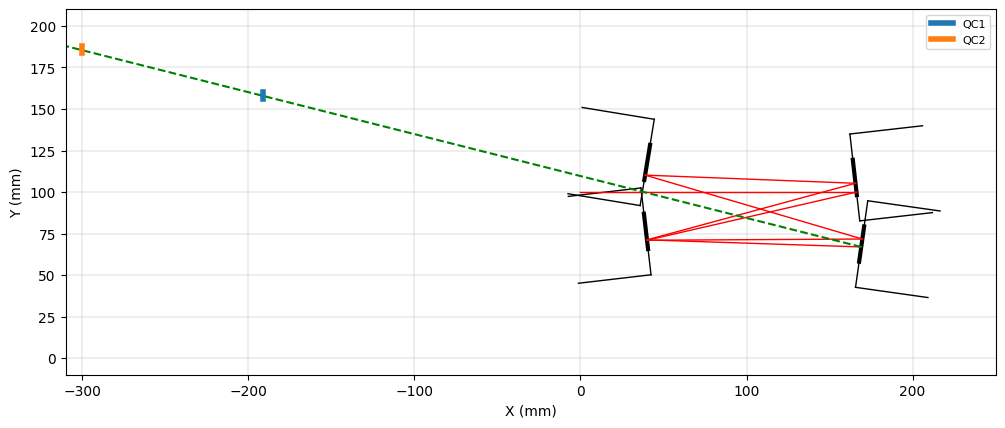

In [69]:
S.simulation(K1[0], K1[1], 
             K2[0], K2[1], 
             K3[0], K3[1],
             K4[0], K4[1], 
             K1[2], K2[2], K3[2], K4[2])

In [70]:
S.simulation_identifier(K1[0], K1[1], 
             K2[0], K2[1], 
             K3[0], K3[1],
             K4[0], K4[1], 
             K1[2], K2[2], K3[2], K4[2])

Exit slope: -0.252548304986
Total length: 1465.062763705709
y191 error: -0.369229382238
y300 error: -0.351464138730
y595 error: -0.299714167768


(-0.2525483049863127,
 1465.062763705709,
 -0.36922938223827373,
 -0.35146413873019355,
 -0.2997141677679451)

In [71]:
mirrors, res, execution = A.execute_OPD_fixed_plan(
    1470, K1, K2, K3, K4,
    hardware=H,
    dry_run=False,
    profile=True,
    qc_safety_limit=3.5,
    qc_step_tolerance=0.20,
    max_rotation_chunk_substeps=2,
    max_rotation_chunks_per_step=20,
    rotation_settle_delay=0.5,
    linear_settle_delay=2.0,
    max_total_steps=70,
)

[execute_fixed_OPD 17.036s] start target_OPD=1470.000 dry_run=False planned_steps=39 failure=None ignored_planner_failure=False
Moving KDC101 stage 27266900 to 4.92836451796898 mm
Move complete for 27266900
[execute_fixed_OPD 21.058s] step=1/39 actuator=M1.dx miss=2.425 qc_x=(2.531,3.006)
[execute_fixed_OPD 29.601s] step=2/39 actuator=M2.dangle miss=0.033 qc_x=(-1.477,-3.019)
[execute_fixed_OPD 38.142s] step=3/39 actuator=M3.dangle miss=0.270 qc_x=(2.386,2.990)
[execute_fixed_OPD 46.684s] step=4/39 actuator=M2.dangle miss=0.164 qc_x=(-1.605,-2.967)
[execute_fixed_OPD 55.224s] step=5/39 actuator=M3.dangle miss=0.389 qc_x=(2.243,3.027)
[execute_fixed_OPD 63.771s] step=6/39 actuator=M2.dangle miss=0.057 qc_x=(-1.971,-3.008)
[execute_fixed_OPD 71.813s] step=7/39 actuator=M3.dangle miss=0.356 qc_x=(1.940,2.924)
[execute_fixed_OPD 79.855s] step=8/39 actuator=M2.dangle miss=0.181 qc_x=(-2.113,-2.962)
[execute_fixed_OPD 86.891s] step=9/39 actuator=M1.dangle miss=0.306 qc_x=(2.099,2.916)
[execu

In [72]:
print("success:", execution["success"])
print("failure_reason:", execution["failure_reason"])
print("final_OPD:", execution["final_OPD"])
print("final_OPD_error:", execution["final_OPD_error"])
print("final_qc_y:", execution["final_qc_y"])
print("max_abs_measured_qc:", execution["max_abs_measured_qc"])
print("max_step_target_miss:", execution["max_step_target_miss"])
print("needs_final_recenter:", execution["needs_final_recenter"])

success: False
failure_reason: Fixed-plan final checks failed: final_OPD_within_tolerance
final_OPD: 1476.1816912343293
final_OPD_error: 6.181691234329264
final_qc_y: [1.0539051274978133, 0.7439193298856633]
max_abs_measured_qc: 3.1175664882902487
max_step_target_miss: 2.4245636182360717
needs_final_recenter: True


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Reflection Positions During Fixed-Plan Execution'}, xlabel='Actuator step', ylabel='Reflection position u'>)

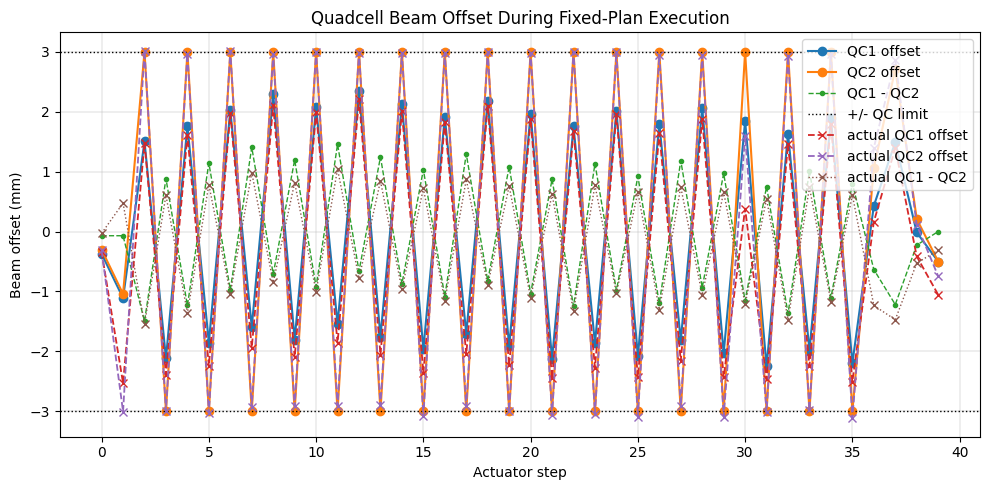

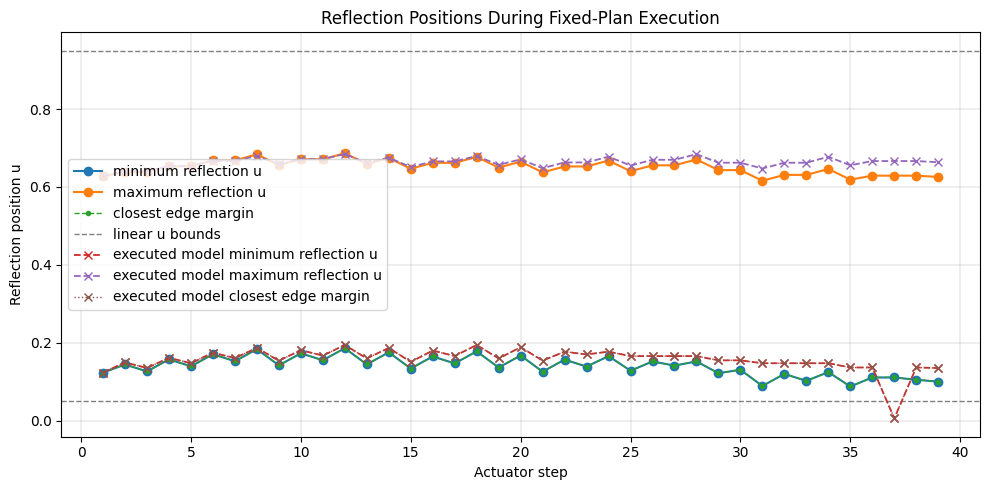

In [73]:
A.plot_fixed_plan_quadcell_overlay(execution)
A.plot_fixed_plan_reflection_u_overlay(execution)

In [67]:
import importlib
A = importlib.reload(A)

qc = H.quads.get_xy_position()
qc1_x, qc2_x = qc[0], qc[2]

print("raw qc:", qc)
print("hardware qc x:", qc1_x, qc2_x)
print("sim qc if sign=-1:", -qc1_x, -qc2_x)
print("sim qc if sign=+1:", qc1_x, qc2_x)

print("model qc:", S.quadcell_errors_from_mirrors(K1, K2, K3, K4))

raw qc: [2.6102726283723303, 0.45004700489178107, 3.572655801950523, 0.5261102722050427]
hardware qc x: 2.6102726283723303 3.572655801950523
sim qc if sign=-1: -2.6102726283723303 -3.572655801950523
sim qc if sign=+1: 2.6102726283723303 3.572655801950523


AttributeError: module 'Simulation' has no attribute 'quadcell_errors_from_mirrors'

In [1]:
execution

NameError: name 'execution' is not defined

In [58]:
for s in execution["actuation_plan"]["steps"][:5]:
    print(
        s["step"],
        s["actuator"],
        "cmd=", s["command_value"],
        "OPD=", s["OPD"],
        "qc=", (s["qc1_error"], s["qc2_error"])
    )

1 M1.dx cmd= 1.4242972547661736 OPD= 1450.0 qc= (-0.4807247182268384, -1.4765858326259718)
2 M2.dangle cmd= 0.052903410129673034 OPD= 1451.8647833314953 qc= (2.4090829627650123, 2.9999999993549977)
3 M1.dangle cmd= 0.06403892536219757 OPD= 1449.2604794873323 qc= (-1.6705162092011108, -2.9999999988469312)
4 M2.dangle cmd= 0.07092062887913642 OPD= 1451.755975660241 qc= (2.2024562351542727, 2.999999999244494)
5 M1.dangle cmd= 0.06403117676710224 OPD= 1449.1499318682568 qc= (-1.8769105598170484, -2.999999999629381)


In [59]:
for e in execution["execution_log"]:
    print("\nstep", e["execution_step"], e["actuator"])
    print("command:", e["command_value"])
    print("planned_qc_y:", e["planned_qc_y"])
    print("before_qc_y:", e["before_qc_y"])
    print("after_qc_y:", e["after_qc_y"])
    print("miss:", e["qc_target_miss"])
    print("detail:", e["detail"])


step 1 M1.dx
command: 1.4242972547661736
planned_qc_y: [0.4807247182268384, 1.4765858326259718]
before_qc_y: [0.28961968158783785, -0.7257726570403511]
after_qc_y: [2.316957452702703, 2.6643479087279927]
miss: 2.186899495767214
detail: {'kind': 'linear', 'serial': '27266900', 'planned_sim_delta': 1.4242972547661736, 'hardware_delta': 1.4242972547661736, 'actual_sim_delta': 1.4243, 'before_position': 1.011, 'after_position': 2.4353}

step 2 M2.dangle
command: 0.052903410129673034
planned_qc_y: [-2.4090829627650123, -2.9999999993549977]
before_qc_y: [2.316957452702703, 2.6643479087279927]
after_qc_y: [2.59159143194286, 3.6347821874601864]
miss: 8.308253671402133
detail: {'kind': 'rotation_fixed_plan', 'controller': 'newport', 'actuator': 3, 'planned_angle_delta': 0.052903410129673034, 'degrees_per_substep': 0.0023, 'target_qc_x': [-2.4090829627650123, -2.9999999993549977], 'target_qc_y': [-2.4090829627650123, -2.9999999993549977], 'start_qc_x': [2.316957452702703, 2.6643479087279927], '

In [37]:
e = execution["execution_log"][0]
print(e["detail"])

{'kind': 'linear', 'serial': '27266900', 'planned_sim_delta': 4.041582190743128, 'hardware_delta': 4.041582190743128, 'actual_sim_delta': 4.04, 'before_position': 0.0, 'after_position': 4.04}


In [8]:
def linear_pos(serial):
    p = H.stages.get_position(serial)
    print(f"{serial} position = {p}")
    return p

def linear_move_relative(serial, delta, settle=2.0):
    p0 = H.stages.get_position(serial)
    print(f"before: {p0}")

    print(f"moving relative by {delta}")
    H.stages.move_relative(serial, delta)

    time.sleep(settle)

    p1 = H.stages.get_position(serial)
    print(f"after: {p1}")
    print(f"software delta: {p1 - p0}")

    return p0, p1

In [9]:
linear_pos("27266900")

27266900 position = 0.024


0.024

In [11]:
linear_move_relative("27266901", -1, settle=2.0)

before: 1.00637
moving relative by -1
Moving KDC101 stage 27266901 to 0.006369999999999987 mm
Move complete for 27266901
after: 0.00637
software delta: -1.0


(1.00637, 0.00637)

In [138]:
H.shutdown()

Shutting down piezos...
Shutting down quadcells...
Shutdown aligner with serial 69253622
Shutdown aligner with serial 69253977
Shutting down KDC101 linear stages...
Shutdown KDC101 linear stage with serial 27266900
Shutdown KDC101 linear stage with serial 27266901
Shutdown KDC101 linear stage with serial 27601694
Shutting down rotation stages...
Shutdown Newport rotation controller newport
All hardware safely shut down.


In [ ]:
linear_pos("27266900")
linear_move_relative("27266900", 0.001, settle=2.0)
linear_move_relative("27266900", -0.001, settle=2.0)

In [75]:
import cv2 as cv

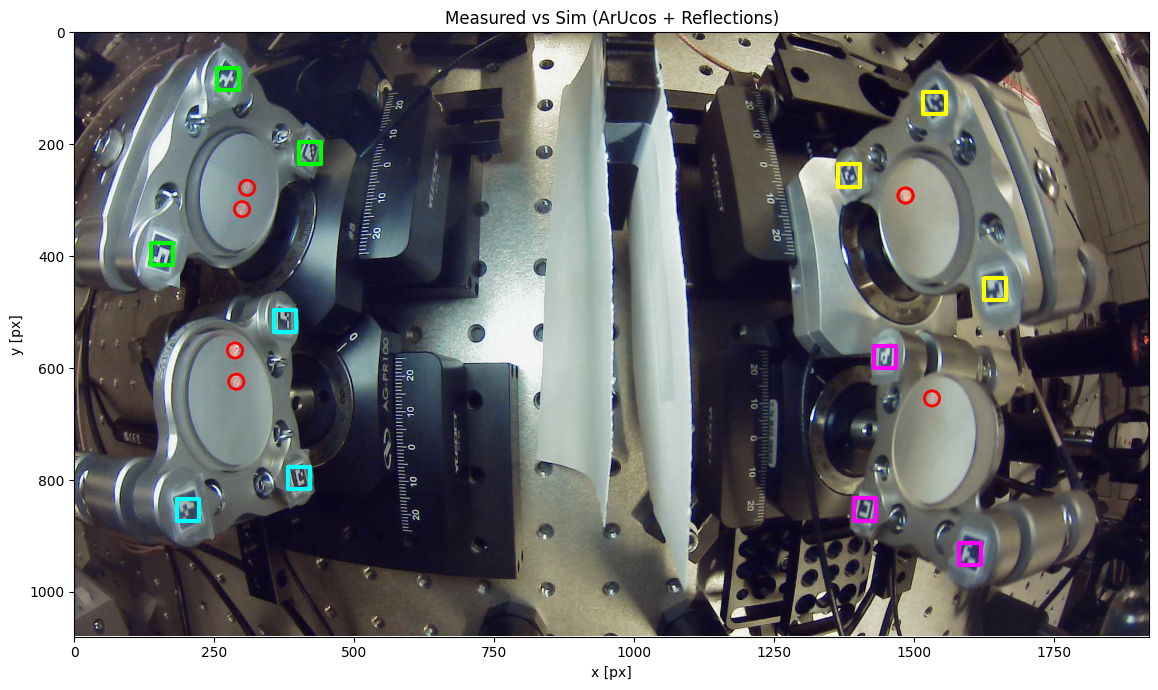

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Measured vs Sim (ArUcos + Reflections)'}, xlabel='x [px]', ylabel='y [px]'>)

In [80]:
# ---- Load images ----
img_light = cv.imread("images/6-08-L4.jpg")
img_dark  = cv.imread("images/6-08-D4.jpg")
gray = cv.cvtColor(img_dark, cv.COLOR_BGR2GRAY)

# ---- Measured points ----
aruco_centers_12 = S.camera_arucos("images/6-08-L4.jpg")                 # list of 12
aruco_meas = S.group_aruco_centers_by_mirror(aruco_centers_12)

refl_meas = S.reflec_pts_cam(gray, show=False)                     # dict M1..M4

# ---- Sim points (from solved theta) ----
M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a = x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[7], x[8], x[9], x[10], x[11]

aruco_sim = S.sim_aruco_pts_by_mirror(M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a)
refl_sim  = S.sim_reflection_pts_by_mirror(M1x, M2x, M3x, M4x, M1y, M2y, M3y, M4y, M1a, M2a, M3a, M4a)

# ---- Overlay plot ----
S.overlay_reflections_and_aruco(
    img_bgr=img_light,
    reflec_meas_by_mirror=refl_meas,
    aruco_meas_by_mirror=aruco_meas,
    reflec_sim_by_mirror=None,
    aruco_sim_by_mirror=None,
    title="Measured vs Sim (ArUcos + Reflections)"
)

In [81]:
res = S.optimize_inverse(M1, M2, M3, M4, img_path_light='images/6-08-L1.jpg', img_path_dark='images/6-08-D1.jpg',
                   qc1_disp=None, qc2_disp=None)

Exit slope: -0.246423177391
Total length: 1494.023637560200
y191 error: -4.660800748686
y300 error: -5.310674413100
y595 error: -7.065837082846
Exit slope: -0.246423177391
Total length: 1494.023645702626
y191 error: -4.660801945125
y300 error: -5.310675609539
y595 error: -7.065838279285
Exit slope: -0.246423177391
Total length: 1494.023636480785
y191 error: -4.660800591722
y300 error: -5.310674256137
y595 error: -7.065836925883
Exit slope: -0.246423177391
Total length: 1494.023648151672
y191 error: -4.660799506388
y300 error: -5.310673170803
y595 error: -7.065835840549
Exit slope: -0.246423177391
Total length: 1494.023636524248
y191 error: -4.660800869048
y300 error: -5.310674533463
y595 error: -7.065837203209
Exit slope: -0.246423177391
Total length: 1494.023638191577
y191 error: -4.660800841459
y300 error: -5.310674505874
y595 error: -7.065837175620
Exit slope: -0.246423177391
Total length: 1494.023637132089
y191 error: -4.660800686432
y300 error: -5.310674350846
y595 error: -7.06583

In [82]:
x = res.x

K1 = np.array([x[0], x[4], x[8]])
K2 = np.array([x[1], x[5], x[9]])
K3 = np.array([x[2], x[6], x[10]])
K4 = np.array([x[3], x[7], x[11]])

In [84]:
K1, K2, K3, K4

(array([161.63958555, 108.76839189,  96.45142482]),
 array([39.47417847, 76.24278375, 96.37998894]),
 array([169.23511135,  68.79466864,  81.77841569]),
 array([ 40.15127225, 117.76531573,  80.78461946]))